In [1]:
import numpy as np
import pkg_resources
import pickle
import matplotlib.pyplot as plt
from pathlib import Path
from flygym.envs.nmf_mujoco import NeuroMechFlyMuJoCo
from tqdm import tqdm, trange
from flygym.util.config import all_leg_dofs

import PIL

import numpy as np

# load PhysicsError
from dm_control.rl.control import PhysicsError
import warnings

In [2]:
# Initialize simulation
run_time = 0.3
nmf = NeuroMechFlyMuJoCo(render_mode='saved',
                         timestep=1e-4,
                         render_config={'playspeed': 0.1, 'camera': 0},
                         init_pose='stretch',
                         actuated_joints=all_leg_dofs,
                         floor_collisions_geoms="all")

In [3]:
# Load recorded data
data_path = Path(pkg_resources.resource_filename('flygym', 'data'))
with open(data_path / 'behavior' / '210902_pr_fly1.pkl', 'rb') as f:
    data = pickle.load(f)

In [4]:
# Interpolate 5x
num_steps = int(run_time / nmf.timestep)
data_block = np.zeros((len(nmf.actuated_joints), num_steps))
measure_t = np.arange(len(data['joint_LFCoxa'])) * data['meta']['timestep']
interp_t = np.arange(num_steps) * nmf.timestep
for i, joint in enumerate(nmf.actuated_joints):
    data_block[i, :] = np.interp(interp_t, measure_t, data[joint])

# Gridsearch for tarsus stiffness and damping

In [5]:
def get_height(nmf, pose_data, verbose=False):
    i = 0
    action = {'joints': pose_data}
    obs, _ = nmf.step(action)

    all_speeds = []

    # more than 
    while np.sum(np.abs(obs["fly"][1])) > 0.5 and i < 5000:
        action = {'joints': pose_data}
        obs, _ = nmf.step(action)
        i += 1
        all_speeds.append(obs["fly"][1])
    
    if verbose:
        print("Final height: ", obs["fly"][0][-1], "reached in", i, "steps")
    
    return obs["fly"][0][-1], np.array(all_speeds)



n_pts = 30
stifnesses = np.logspace(-3, 2, n_pts)
dampings = np.logspace(-3, 2, n_pts)
all_heights = np.zeros((n_pts, n_pts))

verbose = False
if verbose:
    warnings.filterwarnings("default")
else:
    warnings.filterwarnings("ignore")

for i, stiffness in enumerate(tqdm(stifnesses)):
    for j, damping in enumerate(dampings):
        nmf = NeuroMechFlyMuJoCo(render_mode='saved',
                                        timestep=1e-4,
                                        render_config={'playspeed': 0.1, 'camera': 0},
                                        init_pose='stretch',
                                        actuated_joints=all_leg_dofs,
                                        floor_collisions_geoms="all",
                                        physics_config = {'joint_stiffness': 1.0,
                                                        'actuator_kp': 60,
                                                        'tarsus_stiffness': stiffness,
                                                        'tarsus_damping': damping})
        
        try:
            all_heights[i][j], _ = get_height(nmf, data_block[:, 0], verbose=verbose)   
        except PhysicsError:
            all_heights[i][j] = np.nan                                 



100%|██████████| 30/30 [22:33<00:00, 45.12s/it]


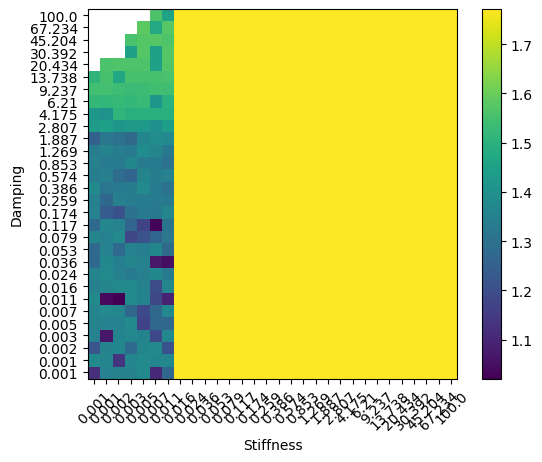

Max height 1.7713933304254565
Min height 1.0209960744035484
Final height:  1.7713933304254565 reached in 0 steps
Viewpoints for max height: 1.7713933304254565  at stiffness: 0.001 and damping: 100.0


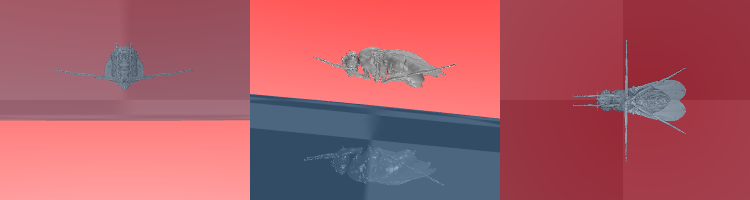

Final height:  1.0209960744035484 reached in 631 steps
Viewpoints for min height: 1.0209960744035484  at stiffness: 0.010826367338740546 and damping: 0.00221221629107045


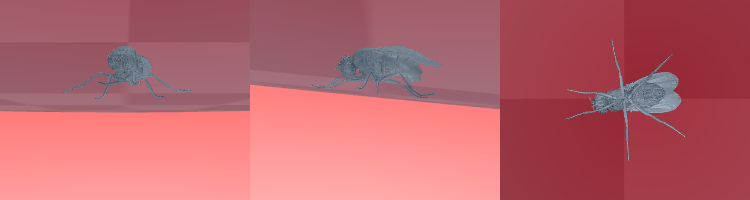

In [6]:
plt.imshow(all_heights, origin='lower')
plt.colorbar()
plt.xlabel("Stiffness")
plt.ylabel("Damping")
plt.xticks(np.arange(n_pts), np.round(stifnesses, 3), rotation=45)
plt.yticks(np.arange(n_pts), np.round(dampings, 3))
plt.show()

i_max, j_max = np.unravel_index(np.nanargmax(all_heights), all_heights.shape)
print(f"Max height {all_heights[i_max, j_max]}")
i_min, j_min = np.unravel_index(np.nanargmin(all_heights), all_heights.shape)
print(f"Min height {all_heights[i_min, j_min]}")


h, w = 200, 250

for i, j, extremum in [[i_max, j_max, "max"], [i_min, j_min, "min"]]:
    nmf = NeuroMechFlyMuJoCo(render_mode='saved',
                                        timestep=1e-4,
                                        render_config={'playspeed': 0.1, 'camera': 0},
                                        init_pose='stretch',
                                        actuated_joints=all_leg_dofs,
                                        floor_collisions_geoms="all",
                                        physics_config = {'joint_stiffness': 1.0,
                                                        'actuator_kp': 60,
                                                        'tarsus_stiffness': stifnesses[i],
                                                        'tarsus_damping': dampings[j]})
    _, _ = get_height(nmf, data_block[:, 0], verbose=True)


    print("Viewpoints for", extremum, "height:", all_heights[i][j], " at stiffness:", stifnesses[i], "and damping:", dampings[j])
    all_viewpoints = []
    for viewpoint in ['camera_front', 'camera_left', 'camera_bottom']:
        all_viewpoints.append(nmf.physics.render(camera_id=f"Animat/{viewpoint}", width=w, height=h))

    im = PIL.Image.fromarray(np.hstack(all_viewpoints))
    #show concatenated image
    display(im)



Final height:  1.771393181865322 reached in 0 steps
Viewpoints for quantile 0.59  height: 1.771393181865322  at stiffness: 0.001 and damping: 0.8531678524172814


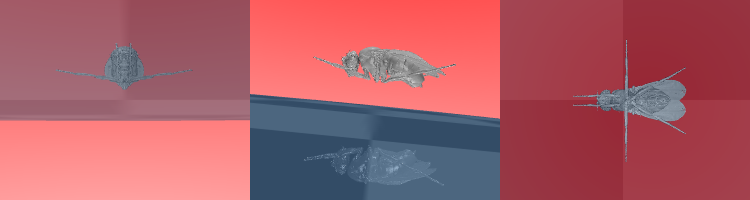

In [7]:
# get the median height parameters and display
quantile = 0.59
index = np.nanargmin(np.abs(all_heights - np.nanquantile(all_heights, quantile)))
i_med, j_med = np.unravel_index(index, all_heights.shape)

nmf = NeuroMechFlyMuJoCo(render_mode='saved',
                                    timestep=1e-4,
                                    render_config={'playspeed': 0.1, 'camera': 0},
                                    init_pose='stretch',
                                    actuated_joints=all_leg_dofs,
                                    floor_collisions_geoms="all",
                                    physics_config = {'joint_stiffness': 1.0,
                                                    'actuator_kp': 60,
                                                    'tarsus_stiffness': stifnesses[i_med],
                                                    'tarsus_damping': dampings[j_med]})
_, _ = get_height(nmf, data_block[:, 0], verbose=True)


print(f"Viewpoints for quantile {quantile}  height:", all_heights[i_med][j_med], " at stiffness:", stifnesses[i_med], "and damping:", dampings[j_med])
all_viewpoints = []
for viewpoint in ['camera_front', 'camera_left', 'camera_bottom']:
    all_viewpoints.append(nmf.physics.render(camera_id=f"Animat/{viewpoint}", width=w, height=h))

im = PIL.Image.fromarray(np.hstack(all_viewpoints))
#show concatenated image
display(im)

# Stifness and Kp

In [8]:
def get_score(nmf, num_timesteps, data_block, verbose=False, ang_weight=0.2):
    score = 0
    obs_list = []

    contact_forces = np.ones((len(nmf.collision_tracked_geoms), num_steps))*np.nan

    try:
        for k in range(num_steps):
            joint_pos = data_block[:, k]
            action = {'joints': joint_pos}
            obs, info = nmf.step(action)
            obs_list.append(obs)
            
            contact_forces[:, k] = obs['contact_forces'].copy()
            # if not touching the floor for the last 20 steps, break
            if np.all(contact_forces[:, k-20:k] <= 0 ) and k > 1000:
                if verbose:
                    print(f"Not touching the floor, breaking {k/num_steps*100:.3}%", f"stifness {stif}, kp {kp}")
                break

    except PhysicsError as pe:
        if verbose:
            print("Physics error")
        score = np.nan
    else:
        distance = -1 * (obs_list[0]["fly"][0][0] - obs_list[-1]["fly"][0][0])
        ang_diff = np.abs(obs_list[-1]["fly"][1] - obs_list[0]["fly"][1])
        # distance is probably going to stay between 0 and 1, the angle should evolve between 0 and 1 but scaled to have a lower importance
        score = distance - np.mean(ang_diff / (np.pi / 2)) * ang_weight
        
    return score

In [9]:
n_pts = 30
stifnesses =  np.logspace(-3, 1, n_pts)
n_pts_div2 = int(n_pts//2)
kps = np.linspace(0.5, 62, n_pts)
all_scores = np.zeros((n_pts, n_pts))

verbose = False
if verbose:
    warnings.filterwarnings("default")
else:
    warnings.filterwarnings("ignore")

for i, kp in enumerate(tqdm(kps)):
    for j, stif in enumerate(stifnesses):
        if verbose:
            print(f"Print round {i*n_pts+j} of {n_pts**2}, kp {kp}, stif {stif}")
        nmf = NeuroMechFlyMuJoCo(render_mode='headless',
                                    timestep=1e-4,
                                    render_config={'playspeed': 0.1, 'camera': 0},
                                    init_pose='stretch',
                                    actuated_joints=all_leg_dofs,
                                    floor_collisions_geoms="all",
                                    physics_config = {'joint_stiffness': stif,
                                                      'actuator_kp': kp})
        
        all_scores[i, j] = get_score(nmf, num_steps, data_block, verbose=verbose)

100%|██████████| 30/30 [54:21<00:00, 108.71s/it]


In [10]:
all_scores = -1*np.array(all_scores)

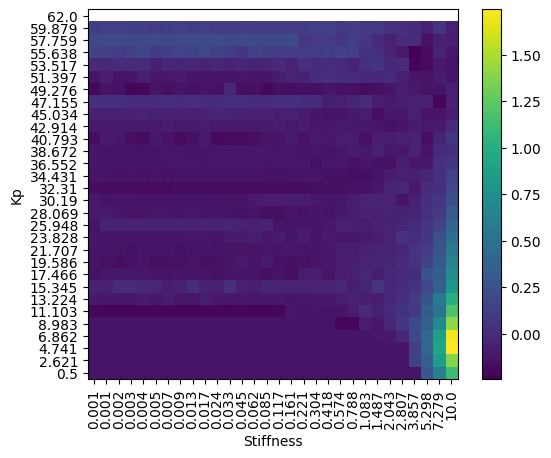

Max score 1.744575136922865
Max distance at stifness:10.000, KP:4.741


In [11]:
plt.imshow(all_scores, origin='lower')
plt.colorbar()
plt.xlabel("Stiffness")
plt.ylabel("Kp")
plt.xticks(np.arange(n_pts), np.round(stifnesses, 3), rotation=90)
plt.yticks(np.arange(n_pts), np.round(kps, 3))
plt.show()

i_max, j_max = np.unravel_index(np.nanargmax(all_scores), all_scores.shape)
print(f"Max score {all_scores[i_max, j_max]}")
print(f"Max distance at stifness:{stifnesses[j_max]:.3f}, KP:{kps[i_max]:.3f}")

kpmax_id = i_max.copy()

In [12]:
nmf = NeuroMechFlyMuJoCo(render_mode='saved',
                                timestep=1e-4,
                                render_config={'playspeed': 0.1, 'camera': 0},
                                init_pose='stretch',
                                actuated_joints=all_leg_dofs,
                                floor_collisions_geoms="all",
                                physics_config = {'joint_stiffness': stifnesses[j_max],
                                                  'actuator_kp': kps[i_max]})

# Run simulation
obs, info = nmf.reset()

obs_list = [obs]
for i in trange(num_steps):
    joint_pos = data_block[:, i]
    action = {'joints': joint_pos}
    obs, info = nmf.step(action)
    nmf.render()
    obs_list.append(obs)

100%|██████████| 2999/2999 [00:07<00:00, 419.42it/s]


In [13]:
video_path = Path('kin_replay/video_stiff_kp_gridsearch_res.mp4')
nmf.save_video(video_path)

from ipywidgets import Video
Video.from_file(video_path)

Video(value=b'\x00\x00\x00 ftypisom\x00\x00\x02\x00isomiso2avc1mp41\x00\x00\x00\x08free...')

# Stifness and damping

In [14]:
n_pts = 30
stifnesses =  np.logspace(-3, 1, n_pts)
n_pts_div2 = int(n_pts//2)
dampings = np.logspace(-3, 1, n_pts)
all_scores = np.zeros((n_pts, n_pts))

verbose = False
if verbose:
    warnings.filterwarnings("default")
else:
    warnings.filterwarnings("ignore")

for i, damp in enumerate(tqdm(dampings)):
    for j, stif in enumerate(stifnesses):
        if verbose:
            print(f"Print round {i*n_pts+j} of {n_pts**2}, damping {damp}, stif {stif}")
        nmf = NeuroMechFlyMuJoCo(render_mode='headless',
                                    timestep=1e-4,
                                    render_config={'playspeed': 0.1, 'camera': 0},
                                    init_pose='stretch',
                                    actuated_joints=all_leg_dofs,
                                    floor_collisions_geoms="all",
                                    physics_config = {'joint_stiffness': stif,
                                                      'joint_damping': damp,
                                                      'actuator_kp': kps[kpmax_id]})
        
        all_scores[i, j] = get_score(nmf, num_steps, data_block, verbose=verbose, ang_weight=2.0)

100%|██████████| 30/30 [20:33:35<00:00, 2467.19s/it]   


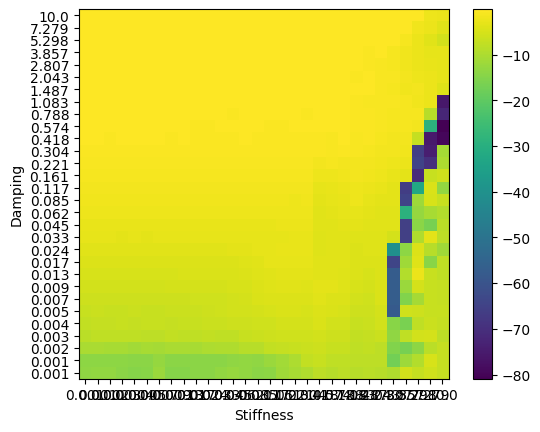

Max score -0.07235803836228094
Max distance at stifness:1.083,  damping:0.788


In [15]:
plt.imshow(all_scores, origin='lower')
plt.colorbar()
plt.xlabel("Stiffness")
plt.ylabel("Damping")
plt.xticks(np.arange(n_pts), np.round(stifnesses, 3))
plt.yticks(np.arange(n_pts), np.round(dampings, 3))
plt.show()

i_max, j_max = np.unravel_index(np.nanargmax(all_scores), all_scores.shape)
print(f"Max score {all_scores[i_max, j_max]}")
print(f"Max distance at stifness:{stifnesses[i_max]:.3f},  damping:{dampings[j_max]:.3f}")


In [16]:

nmf = NeuroMechFlyMuJoCo(render_mode='saved',
                                timestep=1e-4,
                                render_config={'playspeed': 0.1, 'camera': 0},
                                init_pose='stretch',
                                actuated_joints=all_leg_dofs,
                                floor_collisions_geoms="all",
                                physics_config = {'joint_stiffness': stifnesses[j_max],
                                                  'joint_damping': dampings[i_max],
                                                  'actuator_kp': kps[kpmax_id]})

# Run simulation
obs, info = nmf.reset()

obs_list = [obs]
for i in trange(num_steps):
    joint_pos = data_block[:, i]
    action = {'joints': joint_pos}
    obs, info = nmf.step(action)
    nmf.render()
    obs_list.append(obs)

100%|██████████| 2999/2999 [00:07<00:00, 398.35it/s]


In [17]:
video_path = Path('kin_replay/video_stiff_damping_gridsearch_res.mp4')
nmf.save_video(video_path)

from ipywidgets import Video
Video.from_file(video_path)

Video(value=b'\x00\x00\x00 ftypisom\x00\x00\x02\x00isomiso2avc1mp41\x00\x00\x00\x08free...')

: 